# Undervalued Players Report

In this notebook I estimate expected market value from performance data, then compare it with real market value.
If expected value is higher than observed value, I treat that player as a possible undervalued target.

Workflow:
1. Load data and do a quick sanity check.
2. Build a position-specific Lasso baseline.
3. Review results and improve the setup.
4. Build an updated version with `age_squared` and outlier control.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 140)
pd.set_option('display.float_format', lambda x: f"{x:,.4f}")

notebook_dir = Path.cwd()
project_root = notebook_dir.parent.parent if notebook_dir.name == 'undervalued players' else notebook_dir
data_path = project_root / 'data' / 'model_ready' / 'tm_fbref_merged_ready.csv'

df = pd.read_csv(data_path)


## 1. Data Check

Before modeling, I check basic dataset quality:
- table shape
- position distribution
- market value distribution
- Pearson correlation overview

This is a sanity check, not a final conclusion.
It helps confirm that market value is strongly right-skewed.
Because of that, I use log market value as the regression target later.

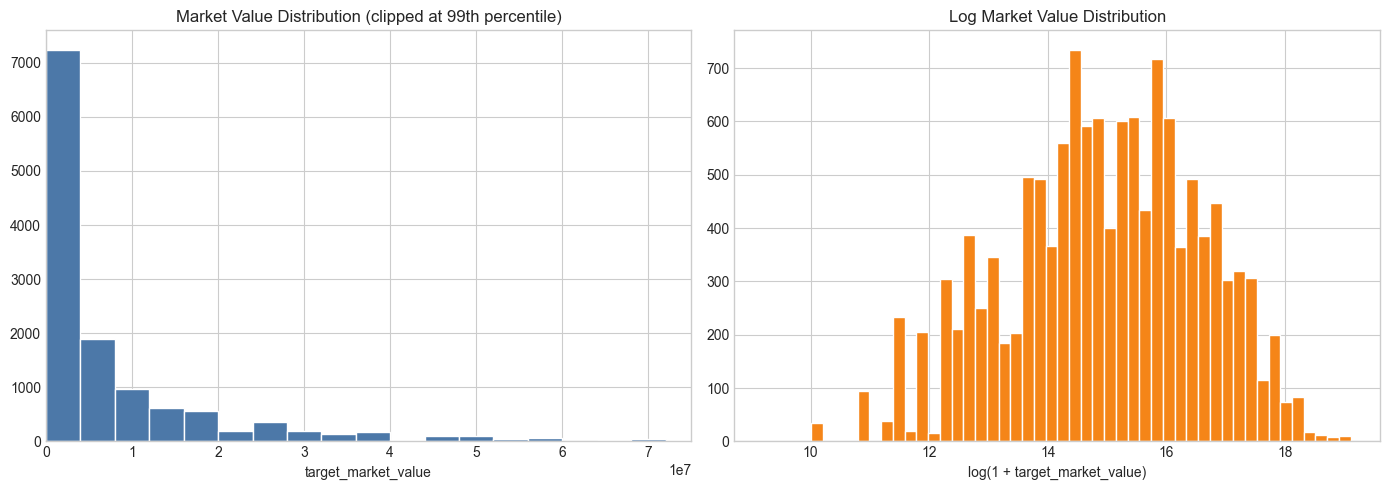

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['target_market_value'], bins=50, color='#4C78A8', edgecolor='white')
axes[0].set_xlim(0, df['target_market_value'].quantile(0.99))
axes[0].set_title('Market Value Distribution (clipped at 99th percentile)')
axes[0].set_xlabel('target_market_value')

axes[1].hist(np.log1p(df['target_market_value']), bins=50, color='#F58518', edgecolor='white')
axes[1].set_title('Log Market Value Distribution')
axes[1].set_xlabel('log(1 + target_market_value)')

plt.tight_layout()
plt.show()


## 2. Model 1: Position-Specific Lasso

My first model is split by position.
I do not mix GK, DF, MF, and FW in one equation because value logic is different by role.

Inside each position subset, I:
- clean data
- create dummies for categorical features
- standardize numeric features
- train Lasso with cross-validation

I also plot CV RMSE vs `log(alpha)` so regularization choice is visible.
After that, I show a compact summary table and top coefficients per position.

In [2]:
model_1_data = df.copy()
model_1_data['log_market_value'] = np.log1p(model_1_data['target_market_value'])
drop_columns_model_1 = [
    'player_url', 'tm_url', 'fbref_url', 'fbref_player_name', 'player',
    'target_market_value', 'name_key', 'method', 'season_end_year', 'squad'
]
for column in drop_columns_model_1:
    if column in model_1_data.columns:
        model_1_data = model_1_data.drop(columns=column)
numeric_columns_model_1 = model_1_data.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns_model_1 = [col for col in numeric_columns_model_1 if col != 'log_market_value']
categorical_columns_model_1 = model_1_data.select_dtypes(include=['object', 'category']).columns.tolist()
model_1_data[numeric_columns_model_1] = model_1_data[numeric_columns_model_1].fillna(0)
for column in categorical_columns_model_1:
    model_1_data[column] = model_1_data[column].fillna('Unknown')


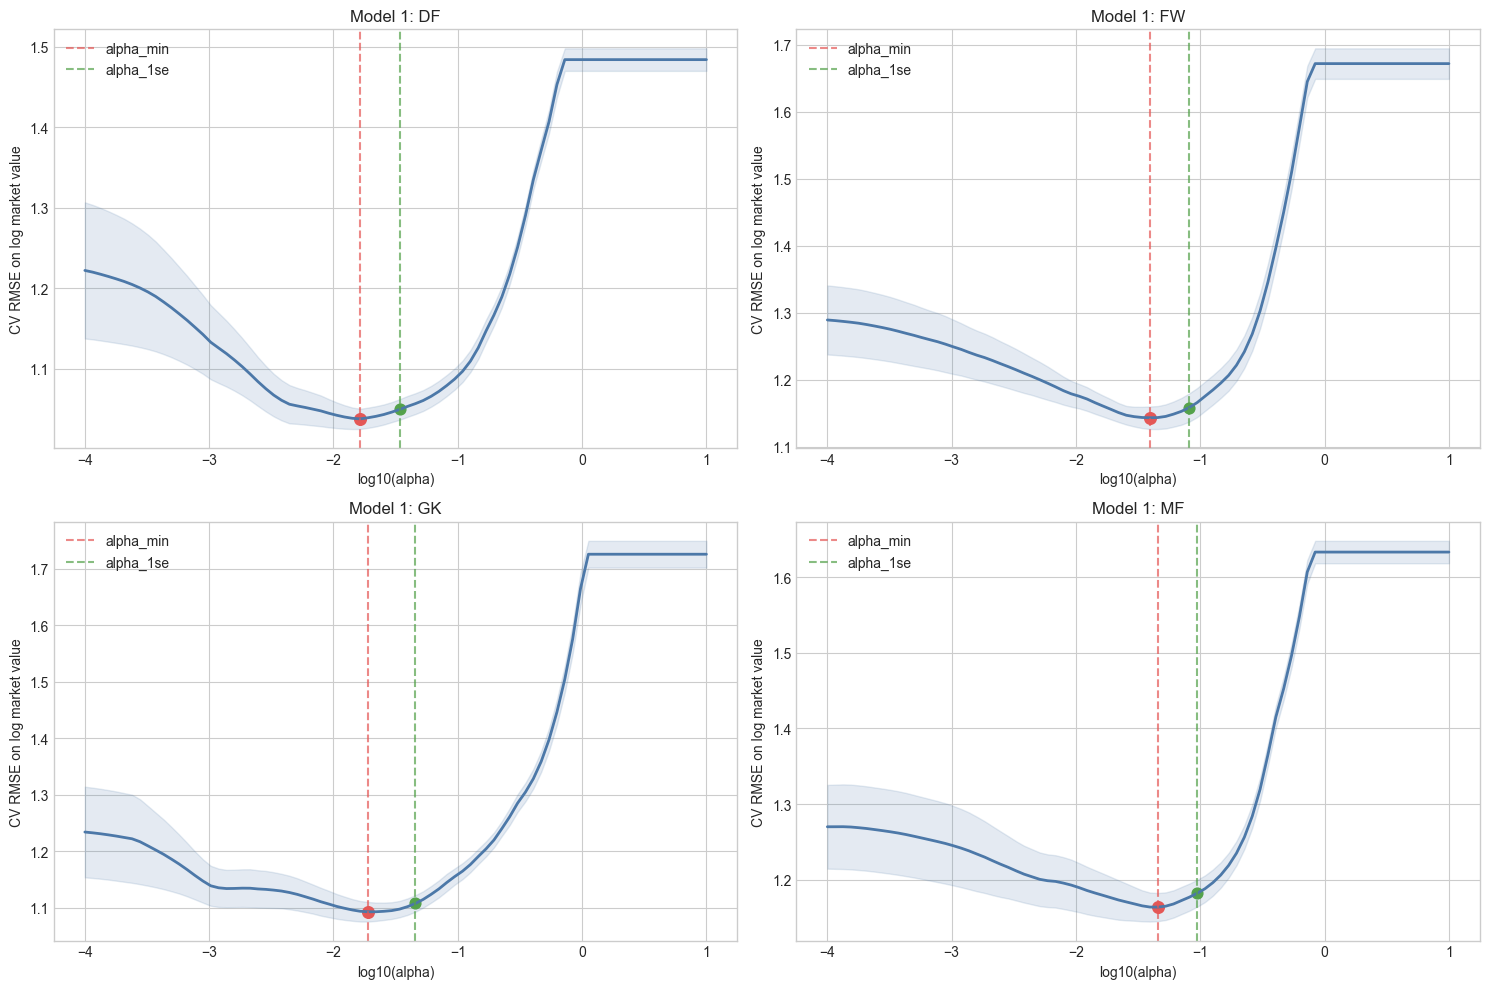

,position,players,cv_folds,alpha_min,alpha_1se,selected_alpha,cv_rmse_log,non_zero_features
0,DF,5108,5,0.0164,0.0340,0.0340,1.0377,35
1,FW,2308,5,0.0393,0.0815,0.0815,1.1435,19
2,GK,1767,5,0.0190,0.0455,0.0455,1.0927,30
3,MF,3699,5,0.0455,0.0943,0.0943,1.1638,15


,player,season_end_year,age,position_group_model,comp,target_market_value,expected_market_value_raw,undervaluation_raw
6730,Mohamed Salah,2025,32.0000,FW,Premier League,"55,000,000.0000","167,674,922.9410","112,674,922.9410"
539,Aymeric Laporte,2022,27.0000,DF,Premier League,"45,000,000.0000","131,962,502.3021","86,962,502.3021"
2269,JoÃ«l Matip,2022,29.0000,DF,Premier League,"18,000,000.0000","88,717,862.0352","70,717,862.0352"
6727,Mohamed Salah,2022,29.0000,FW,Premier League,"90,000,000.0000","142,680,477.2543","52,680,477.2543"
4928,Virgil van Dijk,2022,30.0000,DF,Premier League,"55,000,000.0000","103,098,966.2339","48,098,966.2339"
10879,Jordan Henderson,2022,31.0000,MF,Premier League,"15,000,000.0000","62,610,019.3198","47,610,019.3198"
4993,William Saliba,2024,23.0000,DF,Premier League,"80,000,000.0000","126,951,579.5751","46,951,579.5751"
2298,John Stones,2021,26.0000,DF,Premier League,"30,000,000.0000","73,610,449.1781","43,610,449.1781"
7084,Sadio ManÃ©,2022,29.0000,FW,Premier League,"70,000,000.0000","113,497,756.9296","43,497,756.9296"
5898,Gabriel Jesus,2022,24.0000,FW,Premier League,"50,000,000.0000","93,459,372.2860","43,459,372.2860"


In [5]:
positions = sorted(model_1_data['position_group_model'].dropna().unique())
model_1_results = []
model_1_metrics = []
model_1_feature_importance = {}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, pos in enumerate(positions):
    pos_data = model_1_data[model_1_data['position_group_model'] == pos].copy()
    pos_data = pos_data.drop(columns=['position_group_model'])

    y_pos = pos_data['log_market_value']
    X_raw_pos = pos_data.drop(columns=['log_market_value'])

    cat_cols_pos = X_raw_pos.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols_pos = X_raw_pos.select_dtypes(exclude=['object', 'category']).columns.tolist()

    X_pos = pd.get_dummies(X_raw_pos, columns=cat_cols_pos, drop_first=True)
    if num_cols_pos:
        scaler_pos = StandardScaler()
        X_pos[num_cols_pos] = scaler_pos.fit_transform(X_pos[num_cols_pos].astype(float))

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    alphas = np.logspace(-4, 1, 80)

    lasso_cv_pos = LassoCV(alphas=alphas, cv=cv, random_state=42, max_iter=20000)
    lasso_cv_pos.fit(X_pos, y_pos)

    rmse_path = np.sqrt(lasso_cv_pos.mse_path_)
    mean_rmse = np.mean(rmse_path, axis=1)
    se_rmse = np.std(rmse_path, axis=1, ddof=1) / np.sqrt(5)
    alphas_fitted = lasso_cv_pos.alphas_

    min_rmse_idx = np.argmin(mean_rmse)
    best_alpha_min = alphas_fitted[min_rmse_idx]
    rmse_threshold = mean_rmse[min_rmse_idx] + se_rmse[min_rmse_idx]
    best_alpha_1se = best_alpha_min

    for i, alpha_value in enumerate(alphas_fitted):
        if mean_rmse[i] <= rmse_threshold:
            best_alpha_1se = alpha_value
            break

    final_model_pos = Lasso(alpha=best_alpha_1se, random_state=42, max_iter=20000)
    final_model_pos.fit(X_pos, y_pos)
    y_pred_pos = final_model_pos.predict(X_pos)

    results_pos = df.loc[X_pos.index, ['player', 'season_end_year', 'age', 'position_group_model', 'comp', 'target_market_value']].copy()
    results_pos['predicted_log_value'] = y_pred_pos
    results_pos['expected_market_value_raw'] = np.expm1(y_pred_pos)
    results_pos['undervaluation_raw'] = results_pos['expected_market_value_raw'] - results_pos['target_market_value']
    model_1_results.append(results_pos)

    coefficients_pos = pd.Series(final_model_pos.coef_, index=X_pos.columns)
    important_df = coefficients_pos[coefficients_pos != 0].rename('coefficient').reset_index()
    important_df.columns = ['feature', 'coefficient']
    important_df['abs_coefficient'] = important_df['coefficient'].abs()
    important_df = important_df.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)
    model_1_feature_importance[pos] = important_df

    model_1_metrics.append(
        {
            'position': pos,
            'players': len(pos_data),
            'cv_folds': 5,
            'alpha_min': best_alpha_min,
            'alpha_1se': best_alpha_1se,
            'selected_alpha': best_alpha_1se,
            'cv_rmse_log': mean_rmse[min_rmse_idx],
            'non_zero_features': int((coefficients_pos != 0).sum()),
        }
    )

    ax = axes[idx]
    ax.plot(np.log10(alphas_fitted), mean_rmse, color='#4C78A8', linewidth=2)
    ax.fill_between(
        np.log10(alphas_fitted),
        mean_rmse - se_rmse,
        mean_rmse + se_rmse,
        color='#4C78A8',
        alpha=0.15,
    )
    ax.axvline(np.log10(best_alpha_min), linestyle='--', color='#E45756', alpha=0.7, label='alpha_min')
    ax.axvline(np.log10(best_alpha_1se), linestyle='--', color='#54A24B', alpha=0.7, label='alpha_1se')
    ax.scatter(np.log10(best_alpha_min), mean_rmse[min_rmse_idx], color='#E45756', s=70)
    ax.scatter(np.log10(best_alpha_1se), mean_rmse[np.where(alphas_fitted == best_alpha_1se)[0][0]], color='#54A24B', s=60)
    ax.set_title(f'Model 1: {pos}')
    ax.set_xlabel('log10(alpha)')
    ax.set_ylabel('CV RMSE on log market value')
    ax.legend()

plt.tight_layout()
plt.show()

model_1_metrics_df = pd.DataFrame(model_1_metrics).sort_values('position').reset_index(drop=True)
final_results_df_model_1 = pd.concat(model_1_results, ignore_index=True).sort_values('undervaluation_raw', ascending=False)

display(model_1_metrics_df)
display(final_results_df_model_1[['player', 'season_end_year', 'age', 'position_group_model', 'comp', 'target_market_value', 'expected_market_value_raw', 'undervaluation_raw']].head(20))

final_results_df_model_1.to_csv('model_B_undervalued_players_by_pos.csv', index=False)


In [6]:
model_1_top_features = {}
for pos in positions:
    important_df = model_1_feature_importance[pos].head(10).copy()
    model_1_top_features[pos] = important_df
    print(f'Top 10 coefficients in model 1 for {pos}')
    display(important_df)


Top 10 coefficients in model 1 for DF


,feature,coefficient,abs_coefficient
0,league_strength,0.3766,0.3766
1,age,-0.2433,0.2433
2,cmp_percent_total,0.2172,0.2172
3,xgplus_per_minus_team_success_xg,0.1923,0.1923
4,plus_per_minus_team_success,0.1885,0.1885
5,dist_standard,0.1391,0.1391
6,ppm_team_success,0.1341,0.1341
7,cmp_percent_long,0.1264,0.1264
8,succ_percent_take,0.1073,0.1073
9,aerial_win_pct,0.1000,0.1000


Top 10 coefficients in model 1 for FW


,feature,coefficient,abs_coefficient
0,league_strength,0.3052,0.3052
1,plus_per_minus_team_success,0.2537,0.2537
2,g_per_sot_standard,0.2203,0.2203
3,pk_success_rate,0.1627,0.1627
4,xgplus_per_minus_team_success_xg,0.1511,0.1511
5,cmp_percent_medium,0.1418,0.1418
6,succ_percent_take,0.1406,0.1406
7,avrg_dist_per_carry,0.1286,0.1286
8,cmp_percent_long,0.1279,0.1279
9,ppm_team_success,0.1261,0.1261


Top 10 coefficients in model 1 for GK


,feature,coefficient,abs_coefficient
0,aerial_win_pct,0.4534,0.4534
1,league_strength,0.2787,0.2787
2,cmp_percent_long,0.2052,0.2052
3,ppm_team_success,0.1861,0.1861
4,comp_Serie A,-0.1784,0.1784
5,age,-0.1729,0.1729
6,cmp_percent_short,0.1701,0.1701
7,succ_percent_take,0.1397,0.1397
8,plus_per_minus_team_success,0.1358,0.1358
9,avgdist_sweeper,0.1343,0.1343


Top 10 coefficients in model 1 for MF


,feature,coefficient,abs_coefficient
0,league_strength,0.3045,0.3045
1,dist_standard,0.2442,0.2442
2,plus_per_minus_team_success,0.1892,0.1892
3,ppm_team_success,0.1447,0.1447
4,xgplus_per_minus_team_success_xg,0.1324,0.1324
5,tklw_win_rate,0.1303,0.1303
6,cmp_percent_long,0.1152,0.1152
7,g_per_sot_standard,0.1151,0.1151
8,succ_percent_take,0.1150,0.1150
9,aerial_win_pct,0.0912,0.0912


## 3. Model 2: With some updates

Model 1 was useful, but I wanted to improve two points.

First, age effect is usually non-linear.
So I keep `age` and add `age_squared` to capture a curved pattern.

Second, extreme market values can distort fit.
I winsorize market value inside each position group at 5th and 95th percentiles.
This keeps all rows but reduces outlier impact.

I also remove `league_strength` and `squad` in this version to reduce team identity effect.
For alpha, I select the value with minimum CV RMSE.

In [3]:
model_2_data = df.copy()
model_2_data['age_for_curve'] = model_2_data['age'].fillna(model_2_data['age'].median())
model_2_data['age_squared'] = model_2_data['age_for_curve'] ** 2

winsorized_targets = []
for pos in sorted(model_2_data['position_group_model'].dropna().unique()):
    pos_mask = model_2_data['position_group_model'] == pos
    lower_bound = model_2_data.loc[pos_mask, 'target_market_value'].quantile(0.05)
    upper_bound = model_2_data.loc[pos_mask, 'target_market_value'].quantile(0.95)
    clipped_values = model_2_data.loc[pos_mask, 'target_market_value'].clip(lower=lower_bound, upper=upper_bound)
    winsorized_targets.append(clipped_values)

winsorized_targets = pd.concat(winsorized_targets).sort_index()
model_2_data['target_market_value_winsorized'] = winsorized_targets
model_2_data['log_market_value'] = np.log1p(model_2_data['target_market_value_winsorized'])

drop_columns_model_2 = [
    'player_url', 'tm_url', 'fbref_url', 'fbref_player_name', 'player',
    'target_market_value', 'target_market_value_winsorized', 'name_key', 'age','method', 'season_end_year', 'league_strength', 'squad', 'age_for_curve'
]

for column in drop_columns_model_2:
    if column in model_2_data.columns:
        model_2_data = model_2_data.drop(columns=column)

numeric_columns_model_2 = model_2_data.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns_model_2 = [col for col in numeric_columns_model_2 if col != 'log_market_value']
categorical_columns_model_2 = model_2_data.select_dtypes(include=['object', 'category']).columns.tolist()

model_2_data[numeric_columns_model_2] = model_2_data[numeric_columns_model_2].fillna(0)
for column in categorical_columns_model_2:
    model_2_data[column] = model_2_data[column].fillna('Unknown')


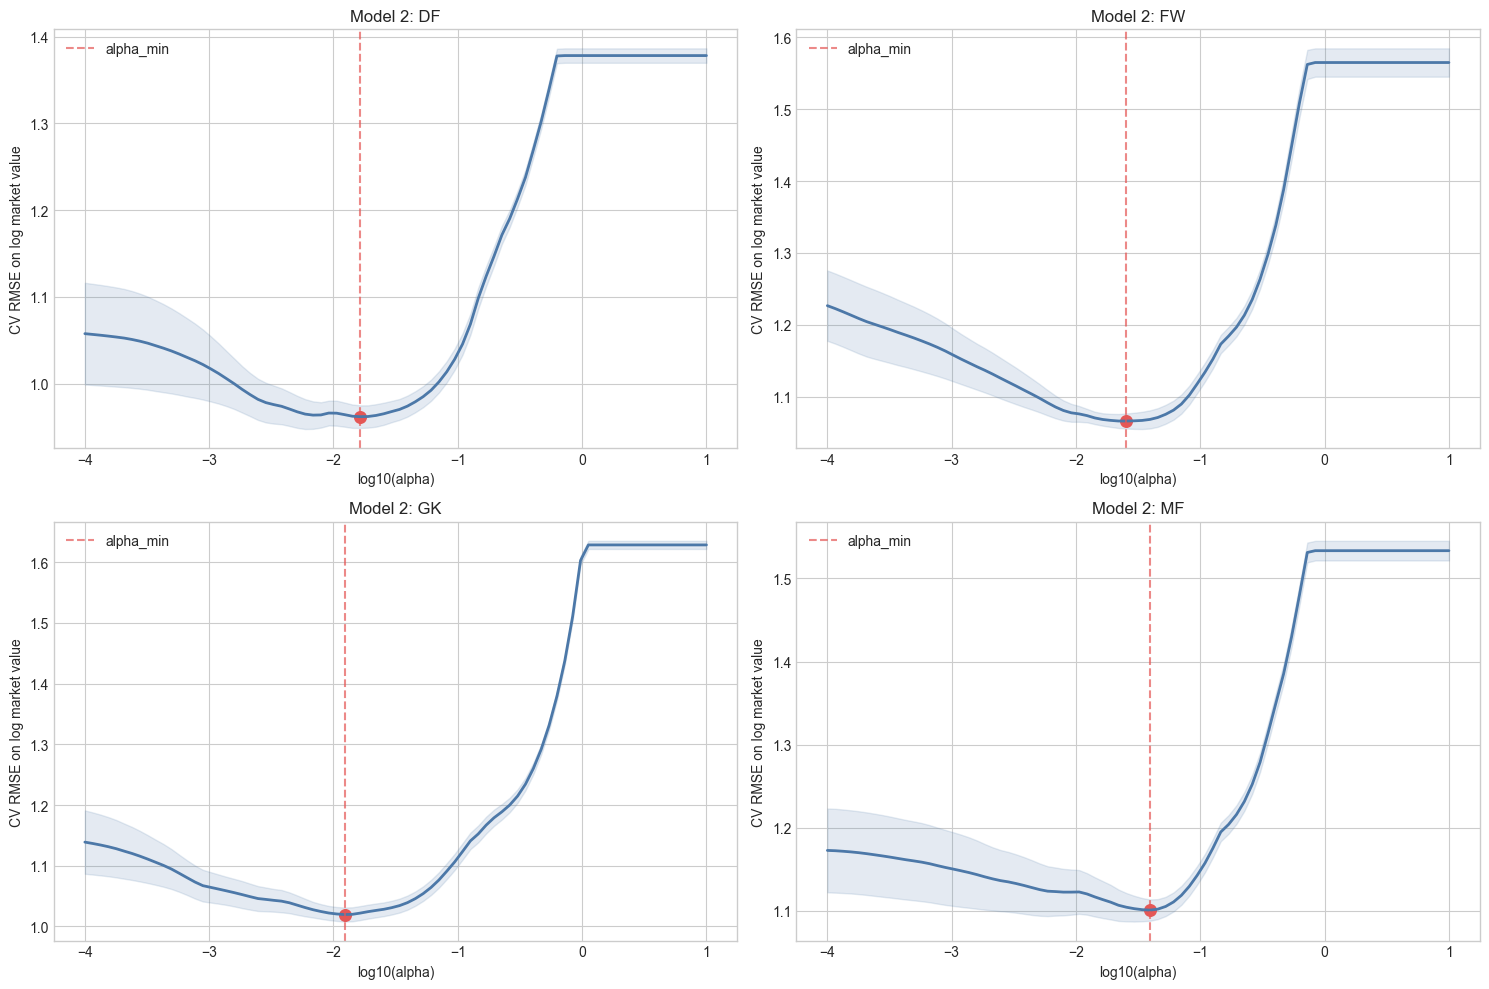

,position,players_used,cv_folds,alpha_min,selected_alpha,cv_rmse_log,non_zero_features
0,DF,5108,10,0.0164,0.0164,0.9618,51
1,FW,2308,10,0.0254,0.0254,1.0662,45
2,GK,1767,10,0.0123,0.0123,1.0196,63
3,MF,3699,10,0.0393,0.0393,1.1008,29


In [4]:
positions_model_2 = sorted(model_2_data['position_group_model'].dropna().unique())
model_2_results = []
model_2_metrics = []
model_2_feature_importance = {}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, pos in enumerate(positions_model_2):
    pos_data = model_2_data[model_2_data['position_group_model'] == pos].copy()
    pos_data = pos_data.drop(columns=['position_group_model'])

    y_pos = pos_data['log_market_value']
    X_raw_pos = pos_data.drop(columns=['log_market_value'])

    cat_cols_pos = X_raw_pos.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols_pos = X_raw_pos.select_dtypes(exclude=['object', 'category']).columns.tolist()

    X_pos = pd.get_dummies(X_raw_pos, columns=cat_cols_pos, drop_first=True)
    if num_cols_pos:
        scaler_pos = StandardScaler()
        X_pos[num_cols_pos] = scaler_pos.fit_transform(X_pos[num_cols_pos].astype(float))

    cv = KFold(n_splits=10, shuffle=True, random_state=490)
    alphas = np.logspace(-4, 1, 80)

    lasso_cv_pos = LassoCV(alphas=alphas, cv=cv, random_state=490, max_iter=20000)
    lasso_cv_pos.fit(X_pos, y_pos)

    rmse_path = np.sqrt(lasso_cv_pos.mse_path_)
    mean_rmse = np.mean(rmse_path, axis=1)
    se_rmse = np.std(rmse_path, axis=1, ddof=1) / np.sqrt(10)
    alphas_fitted = lasso_cv_pos.alphas_

    min_rmse_idx = np.argmin(mean_rmse)
    best_alpha_min = alphas_fitted[min_rmse_idx]

    final_model_pos = Lasso(alpha=best_alpha_min, random_state=490, max_iter=20000)
    final_model_pos.fit(X_pos, y_pos)
    y_pred_pos = final_model_pos.predict(X_pos)

    results_pos = df.loc[X_pos.index, ['player', 'season_end_year', 'age', 'position_group_model', 'comp', 'target_market_value']].copy()
    results_pos['predicted_log_value'] = y_pred_pos
    results_pos['expected_market_value_raw'] = np.expm1(y_pred_pos)
    results_pos['undervaluation_raw'] = results_pos['expected_market_value_raw'] - results_pos['target_market_value']
    model_2_results.append(results_pos)

    coefficients_pos = pd.Series(final_model_pos.coef_, index=X_pos.columns)
    important_df = coefficients_pos[coefficients_pos != 0].rename('coefficient').reset_index()
    important_df.columns = ['feature', 'coefficient']
    important_df['abs_coefficient'] = important_df['coefficient'].abs()
    important_df = important_df.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)
    model_2_feature_importance[pos] = important_df

    model_2_metrics.append(
        {
            'position': pos,
            'players_used': len(pos_data),
            'cv_folds': 10,
            'alpha_min': best_alpha_min,
            'selected_alpha': best_alpha_min,
            'cv_rmse_log': mean_rmse[min_rmse_idx],
            'non_zero_features': int((coefficients_pos != 0).sum()),
        }
    )

    ax = axes[idx]
    ax.plot(np.log10(alphas_fitted), mean_rmse, color='#4C78A8', linewidth=2)
    ax.fill_between(
        np.log10(alphas_fitted),
        mean_rmse - se_rmse,
        mean_rmse + se_rmse,
        color='#4C78A8',
        alpha=0.15,
    )
    ax.axvline(np.log10(best_alpha_min), linestyle='--', color='#E45756', alpha=0.7, label='alpha_min')
    ax.scatter(np.log10(best_alpha_min), mean_rmse[min_rmse_idx], color='#E45756', s=70)
    ax.set_title(f'Model 2: {pos}')
    ax.set_xlabel('log10(alpha)')
    ax.set_ylabel('CV RMSE on log market value')
    ax.legend()

plt.tight_layout()
plt.show()

model_2_metrics_df = pd.DataFrame(model_2_metrics).sort_values('position').reset_index(drop=True)
final_results_df_model_2 = pd.concat(model_2_results, ignore_index=True).sort_values('undervaluation_raw', ascending=False)

display(model_2_metrics_df)

final_results_df_model_2.to_csv('model_B_undervalued_players_improved.csv', index=False)


In [10]:
for pos in positions_model_2:
    print(f'Top 10 coefficients in model 2 for {pos}')
    display(model_2_feature_importance[pos].head(10))

# Export all features used in Model 2 as JSON split by position
import json

features_by_position = {}
for pos in positions_model_2:
    feature_list = model_2_feature_importance[pos]['feature'].tolist()
    features_by_position[pos] = feature_list

export_path = Path(r'C:\Users\User\Desktop\projects\Portfolio\Pet-projects\moneyball-like\data\model_ready\model_2_all_features_by_position.json')
with open(export_path, 'w') as f:
    json.dump(features_by_position, f, indent=2)

print(f'\nExported all Model 2 features to: {export_path}')
for pos, features in features_by_position.items():
    print(f'{pos}: {len(features)} features')

Top 10 coefficients in model 2 for DF


,feature,coefficient,abs_coefficient
0,comp_Premier League,0.7941,0.7941
1,age_squared,-0.3353,0.3353
2,cmp_percent_total,0.2053,0.2053
3,comp_Ligue 1,-0.1797,0.1797
4,plus_per_minus_team_success,0.1706,0.1706
5,xgplus_per_minus_team_success_xg,0.1611,0.1611
6,ppm_team_success,0.1464,0.1464
7,dist_standard,0.1324,0.1324
8,cmp_percent_long,0.1167,0.1167
9,g_per_sot_standard,0.1154,0.1154


Top 10 coefficients in model 2 for FW


,feature,coefficient,abs_coefficient
0,comp_Premier League,0.7150,0.7150
1,g_per_sot_standard,0.2181,0.2181
2,plus_per_minus_team_success,0.2154,0.2154
3,pk_success_rate,0.1904,0.1904
4,ppm_team_success,0.1787,0.1787
5,cmp_percent_medium,0.1646,0.1646
6,succ_percent_take,0.1565,0.1565
7,age_squared,-0.1538,0.1538
8,cmp_percent_long,0.1409,0.1409
9,aerial_win_pct,0.1369,0.1369


Top 10 coefficients in model 2 for GK


,feature,coefficient,abs_coefficient
0,comp_Premier League,0.7416,0.7416
1,aerial_win_pct,0.4377,0.4377
2,age_squared,-0.2679,0.2679
3,cmp_percent_long,0.2208,0.2208
4,ppm_team_success,0.2109,0.2109
5,save_percent,0.1845,0.1845
6,avgdist_sweeper,0.1756,0.1756
7,live_pass_p90,0.1731,0.1731
8,comp_La Liga,0.1524,0.1524
9,def_pen_touches_p90,-0.1504,0.1504


Top 10 coefficients in model 2 for MF


,feature,coefficient,abs_coefficient
0,comp_Premier League,0.6989,0.6989
1,dist_standard,0.2301,0.2301
2,plus_per_minus_team_success,0.1837,0.1837
3,ppm_team_success,0.1586,0.1586
4,tklw_win_rate,0.1584,0.1584
5,xgplus_per_minus_team_success_xg,0.1436,0.1436
6,g_per_sot_standard,0.1334,0.1334
7,aerial_win_pct,0.1284,0.1284
8,age_squared,-0.1243,0.1243
9,succ_percent_take,0.1242,0.1242



Exported all Model 2 features to: C:\Users\User\Desktop\projects\Portfolio\Pet-projects\moneyball-like\data\model_ready\model_2_all_features_by_position.json
DF: 51 features
FW: 45 features
GK: 63 features
MF: 29 features


## 4. Model 3: Reducing Team Context

Model 2 is stronger, but team-related variables still appear as strong signals.
That means part of pricing may come from team context more than player profile.

So in model 3, I keep model 2 setup but remove team-driven variables.
The goal is to see if individual performance features can take more weight.

In [10]:
model_3_data = df.copy()
model_3_data['age_for_curve'] = model_3_data['age'].fillna(model_3_data['age'].median())
model_3_data['age_squared'] = model_3_data['age_for_curve'] ** 2

winsorized_targets_model_3 = []
for pos in sorted(model_3_data['position_group_model'].dropna().unique()):
    pos_mask = model_3_data['position_group_model'] == pos
    lower_bound = model_3_data.loc[pos_mask, 'target_market_value'].quantile(0.05)
    upper_bound = model_3_data.loc[pos_mask, 'target_market_value'].quantile(0.95)
    clipped_values = model_3_data.loc[pos_mask, 'target_market_value'].clip(lower=lower_bound, upper=upper_bound)
    winsorized_targets_model_3.append(clipped_values)

winsorized_targets_model_3 = pd.concat(winsorized_targets_model_3).sort_index()
model_3_data['target_market_value_winsorized'] = winsorized_targets_model_3
model_3_data['log_market_value'] = np.log1p(model_3_data['target_market_value_winsorized'])

team_related_columns = [
    'ppm_team_success',
    'plus_per_minus_team_success',
    'xgplus_per_minus_team_success_xg',
    'xgplus_per_minus_90_team_success_xg',
    'on_minus_off_team_success_xg',
    'ong_team_success_p90',
    'onga_team_success_p90',
    'onxg_team_success_xg_p90'
]

drop_columns_model_3 = [
    'player_url', 'tm_url', 'fbref_url', 'fbref_player_name', 'player',
    'target_market_value', 'target_market_value_winsorized', 'name_key', 'age', 'method',
    'season_end_year', 'league_strength', 'squad', 'age_for_curve'
] + team_related_columns

for column in drop_columns_model_3:
    if column in model_3_data.columns:
        model_3_data = model_3_data.drop(columns=column)

numeric_columns_model_3 = model_3_data.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns_model_3 = [col for col in numeric_columns_model_3 if col != 'log_market_value']
categorical_columns_model_3 = model_3_data.select_dtypes(include=['object', 'category']).columns.tolist()

model_3_data[numeric_columns_model_3] = model_3_data[numeric_columns_model_3].fillna(0)
for column in categorical_columns_model_3:
    model_3_data[column] = model_3_data[column].fillna('Unknown')


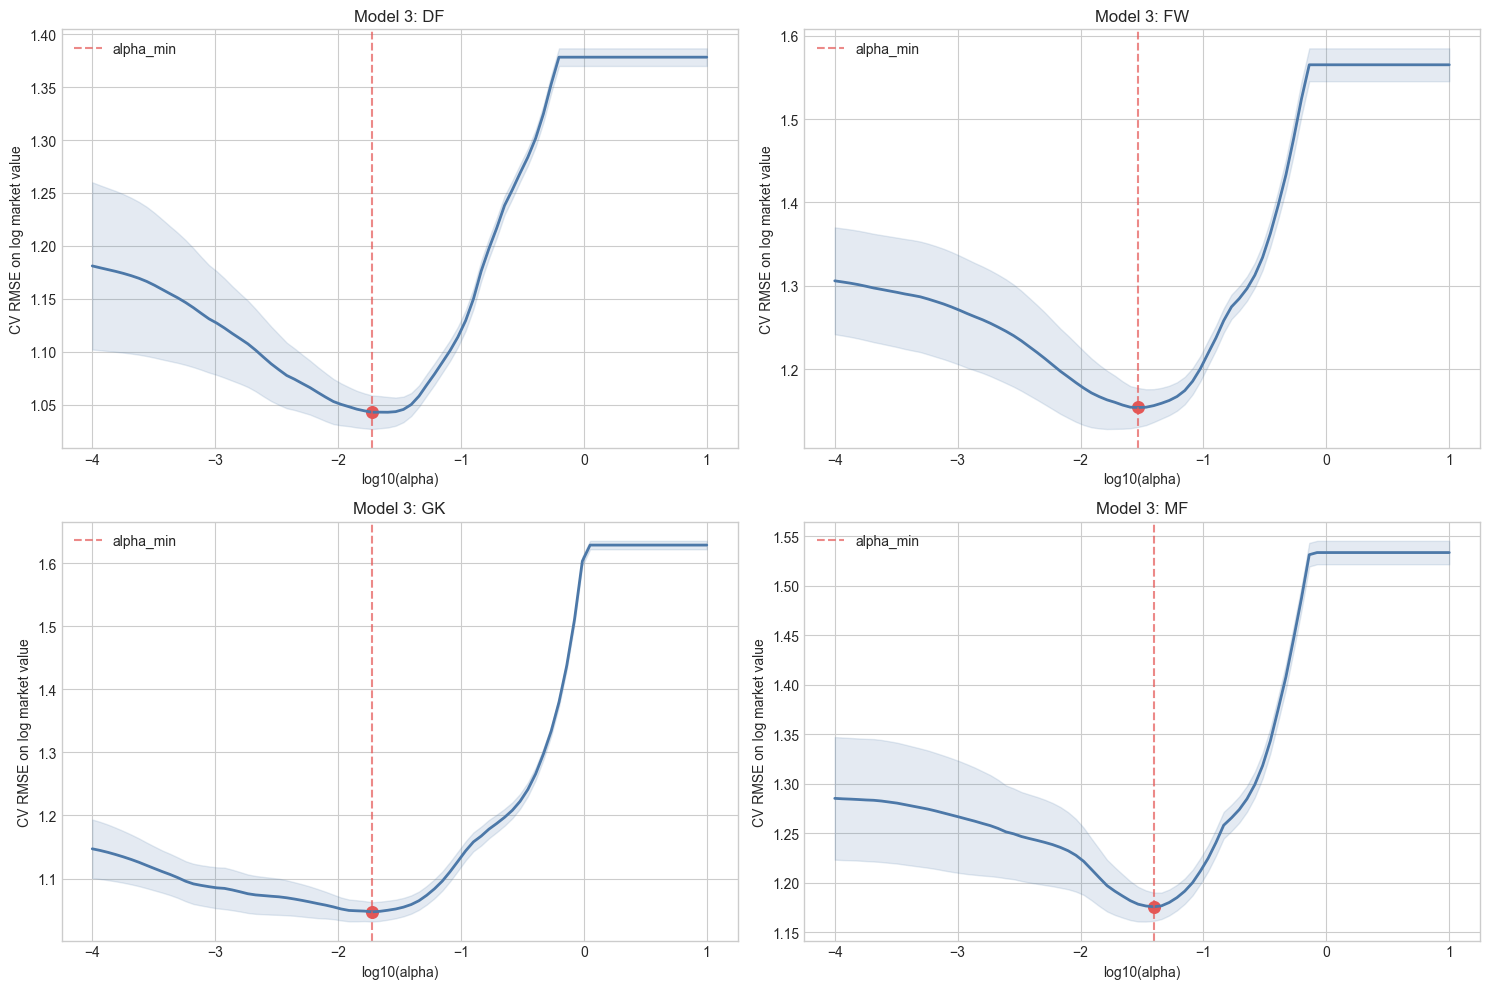

,position,players_used,cv_folds,alpha_min,selected_alpha,cv_rmse_log,non_zero_features
0,DF,5108,10,0.0190,0.0190,1.0430,49
1,FW,2308,10,0.0294,0.0294,1.1539,40
2,GK,1767,10,0.0190,0.0190,1.0472,47
3,MF,3699,10,0.0393,0.0393,1.1756,25


Top 10 coefficients in model 3 for DF


,feature,coefficient,abs_coefficient
0,comp_Premier League,0.7373,0.7373
1,age_squared,-0.3225,0.3225
2,cmp_percent_long,0.2481,0.2481
3,cmp_percent_total,0.2115,0.2115
4,att_long_p90,-0.1935,0.1935
5,comp_Ligue 1,-0.1866,0.1866
6,final_third_p90,0.1850,0.1850
7,avrg_prg_dist_pass,-0.1387,0.1387
8,g_per_sot_standard,0.1282,0.1282
9,aerial_win_pct,0.1194,0.1194


Top 10 coefficients in model 3 for FW


,feature,coefficient,abs_coefficient
0,comp_Premier League,0.7497,0.7497
1,g_per_sot_standard,0.2438,0.2438
2,pk_success_rate,0.2059,0.2059
3,cmp_percent_medium,0.1829,0.1829
4,aerial_win_pct,0.1701,0.1701
5,age_squared,-0.1691,0.1691
6,succ_percent_take,0.1590,0.1590
7,avrg_dist_per_carry,0.1520,0.1520
8,cmp_percent_long,0.1395,0.1395
9,won_aerial_p90,-0.1388,0.1388


Top 10 coefficients in model 3 for GK


,feature,coefficient,abs_coefficient
0,comp_Premier League,0.6697,0.6697
1,aerial_win_pct,0.4431,0.4431
2,cmp_percent_long,0.2839,0.2839
3,age_squared,-0.2447,0.2447
4,save_percent,0.2356,0.2356
5,cs_percent,0.1863,0.1863
6,live_pass_p90,0.1717,0.1717
7,avgdist_sweeper,0.1638,0.1638
8,succ_percent_take,0.1425,0.1425
9,nation_ITA,-0.1332,0.1332


Top 10 coefficients in model 3 for MF


,feature,coefficient,abs_coefficient
0,comp_Premier League,0.6914,0.6914
1,g_per_sot_standard,0.1865,0.1865
2,dist_standard,0.1711,0.1711
3,tklw_win_rate,0.1555,0.1555
4,cmp_percent_long,0.1534,0.1534
5,succ_percent_take,0.1507,0.1507
6,age_squared,-0.1255,0.1255
7,aerial_win_pct,0.1243,0.1243
8,pk_success_rate,0.1114,0.1114
9,sot_percent_standard,0.0901,0.0901


In [11]:
positions_model_3 = sorted(model_3_data['position_group_model'].dropna().unique())
model_3_results = []
model_3_metrics = []
model_3_feature_importance = {}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, pos in enumerate(positions_model_3):
    pos_data = model_3_data[model_3_data['position_group_model'] == pos].copy()
    pos_data = pos_data.drop(columns=['position_group_model'])

    y_pos = pos_data['log_market_value']
    X_raw_pos = pos_data.drop(columns=['log_market_value'])

    cat_cols_pos = X_raw_pos.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols_pos = X_raw_pos.select_dtypes(exclude=['object', 'category']).columns.tolist()

    X_pos = pd.get_dummies(X_raw_pos, columns=cat_cols_pos, drop_first=True)
    if num_cols_pos:
        scaler_pos = StandardScaler()
        X_pos[num_cols_pos] = scaler_pos.fit_transform(X_pos[num_cols_pos].astype(float))

    cv = KFold(n_splits=10, shuffle=True, random_state=490)
    alphas = np.logspace(-4, 1, 80)

    lasso_cv_pos = LassoCV(alphas=alphas, cv=cv, random_state=490, max_iter=20000)
    lasso_cv_pos.fit(X_pos, y_pos)

    rmse_path = np.sqrt(lasso_cv_pos.mse_path_)
    mean_rmse = np.mean(rmse_path, axis=1)
    se_rmse = np.std(rmse_path, axis=1, ddof=1) / np.sqrt(10)
    alphas_fitted = lasso_cv_pos.alphas_

    min_rmse_idx = np.argmin(mean_rmse)
    best_alpha_min = alphas_fitted[min_rmse_idx]

    final_model_pos = Lasso(alpha=best_alpha_min, random_state=490, max_iter=20000)
    final_model_pos.fit(X_pos, y_pos)
    y_pred_pos = final_model_pos.predict(X_pos)

    results_pos = df.loc[X_pos.index, ['player', 'season_end_year', 'age', 'position_group_model', 'comp', 'target_market_value']].copy()
    results_pos['predicted_log_value'] = y_pred_pos
    results_pos['expected_market_value_raw'] = np.expm1(y_pred_pos)
    results_pos['undervaluation_raw'] = results_pos['expected_market_value_raw'] - results_pos['target_market_value']
    model_3_results.append(results_pos)

    coefficients_pos = pd.Series(final_model_pos.coef_, index=X_pos.columns)
    important_df = coefficients_pos[coefficients_pos != 0].rename('coefficient').reset_index()
    important_df.columns = ['feature', 'coefficient']
    important_df['abs_coefficient'] = important_df['coefficient'].abs()
    important_df = important_df.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)
    model_3_feature_importance[pos] = important_df

    model_3_metrics.append(
        {
            'position': pos,
            'players_used': len(pos_data),
            'cv_folds': 10,
            'alpha_min': best_alpha_min,
            'selected_alpha': best_alpha_min,
            'cv_rmse_log': mean_rmse[min_rmse_idx],
            'non_zero_features': int((coefficients_pos != 0).sum()),
        }
    )

    ax = axes[idx]
    ax.plot(np.log10(alphas_fitted), mean_rmse, color='#4C78A8', linewidth=2)
    ax.fill_between(
        np.log10(alphas_fitted),
        mean_rmse - se_rmse,
        mean_rmse + se_rmse,
        color='#4C78A8',
        alpha=0.15,
    )
    ax.axvline(np.log10(best_alpha_min), linestyle='--', color='#E45756', alpha=0.7, label='alpha_min')
    ax.scatter(np.log10(best_alpha_min), mean_rmse[min_rmse_idx], color='#E45756', s=70)
    ax.set_title(f'Model 3: {pos}')
    ax.set_xlabel('log10(alpha)')
    ax.set_ylabel('CV RMSE on log market value')
    ax.legend()

plt.tight_layout()
plt.show()

model_3_metrics_df = pd.DataFrame(model_3_metrics).sort_values('position').reset_index(drop=True)
final_results_df_model_3 = pd.concat(model_3_results, ignore_index=True).sort_values('undervaluation_raw', ascending=False)

display(model_3_metrics_df)

for pos in positions_model_3:
    print(f'Top 10 coefficients in model 3 for {pos}')
    display(model_3_feature_importance[pos].head(10))

final_results_df_model_3.to_csv('model_B_undervalued_players_no_team_context.csv', index=False)


In [12]:
final_undervalued_players = final_results_df_model_3[['player', 'season_end_year', 'age', 'position_group_model', 'comp', 'target_market_value', 'expected_market_value_raw', 'undervaluation_raw']].copy()
display(final_undervalued_players[final_undervalued_players['comp'] != 'Premier League'].head(20))


comparison_df = pd.DataFrame(
    {
        'model': [
            'Model 1: split by position',
            'Model 2: age, age_squared + winsorization',
            'Model 3: model 2 without team metrics'
        ],
        'weighted_cv_rmse_log': [
            np.average(model_1_metrics_df['cv_rmse_log'], weights=model_1_metrics_df['players']),
            np.average(model_2_metrics_df['cv_rmse_log'], weights=model_2_metrics_df['players_used']),
            np.average(model_3_metrics_df['cv_rmse_log'], weights=model_3_metrics_df['players_used']),
        ],
        'players_used': [
            model_1_metrics_df['players'].sum(),
            model_2_metrics_df['players_used'].sum(),
            model_3_metrics_df['players_used'].sum(),
        ],
        'total_non_zero_features': [
            model_1_metrics_df['non_zero_features'].sum(),
            model_2_metrics_df['non_zero_features'].sum(),
            model_3_metrics_df['non_zero_features'].sum(),
        ],
    }
)

display(comparison_df)



,player,season_end_year,age,position_group_model,comp,target_market_value,expected_market_value_raw,undervaluation_raw
6114,Jack Lahne,2020,17.0000,FW,Ligue 1,"900,000.0000","55,664,881.4320","54,764,881.4320"
2600,Kasim Nuhu,2022,26.0000,DF,Bundesliga,"1,000,000.0000","42,945,870.1386","41,945,870.1386"
3579,Mitchel Bakker,2020,19.0000,DF,Ligue 1,"900,000.0000","21,603,768.4214","20,703,768.4214"
10479,Hianga Mananga Mbock,2020,19.0000,MF,Ligue 1,"725,000.0000","21,249,183.7650","20,524,183.7650"
2305,Jon Pacheco,2021,19.0000,DF,La Liga,"200,000.0000","20,452,136.1481","20,252,136.1481"
6777,Myron Boadu,2025,23.0000,FW,Bundesliga,"5,000,000.0000","24,784,034.0304","19,784,034.0304"
6870,Othmane Maamma,2024,18.0000,FW,Ligue 1,"300,000.0000","19,442,947.6751","19,142,947.6751"
6731,Mohamed Sankoh,2022,17.0000,FW,Bundesliga,"1,000,000.0000","19,384,242.0865","18,384,242.0865"
11235,Lucas Ribeiro,2020,20.0000,MF,Bundesliga,"2,300,000.0000","19,434,711.0009","17,134,711.0009"
6762,Moustapha CissÃ©,2022,17.0000,FW,Serie A,"1,000,000.0000","18,021,584.4692","17,021,584.4692"


,model,weighted_cv_rmse_log,players_used,total_non_zero_features
0,Model 1: split by position,1.1004,12882,99
1,"Model 2: age, age_squared + winsorization",1.0283,12882,188
2,Model 3: model 2 without team metrics,1.1015,12882,161


## Conclusion

I started with position-specific Lasso because player roles should be modeled separately.
That baseline already gave a useful shortlist and clear regularization diagnostics.

Then I built model 2 with `age_squared`, target winsorization, and fewer team-context columns.
This version gave the best RMSE in my comparison.

Model 3 removed more team-related variables, but performance became worse.
So team and league context still matters a lot for market value.

Overall, Lasso gives an interpretable baseline.
As next step, I would test non-linear models (for example XGBoost) to try improving accuracy.